## Bibliotecas necessárias

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, random, warnings, sklearn
import plotly.express as px,joblib
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from datetime import datetime
from io import BytesIO

## Funções

In [35]:
def treatData(df):
    # Remover espaços em branco dos nomes das colunas
    df.columns = df.columns.str.strip()

    # Arredondamentos conforme glossário
    df['FCVC'] = df['FCVC'].round().astype(int)  # Frequência de vegetais: 1-3
    df['NCP'] = df['NCP'].round().astype(int)    # Refeições principais: 1-4
    df['CH2O'] = df['CH2O'].round().astype(int)  # Consumo de água: 1-3
    df['FAF'] = df['FAF'].round().astype(int)    # Atividade física: 0-3
    df['TUE'] = df['TUE'].round().astype(int)    # Tempo em dispositivos: 0-2

    # Verificar valores únicos após arredondamento
    print(df[['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']].nunique())

    return df

def isFileExists(file_path):
    if os.path.exists(file_path):
        return True
    else:
        print("Arquivo não encontrado:", file_path)
        return False

## Carregamento dos dados

In [36]:
datasetFile = "data/Obesity.csv"

if not isFileExists(datasetFile): exit()

df_row = pd.read_csv(datasetFile) if datasetFile.lower().endswith(
        ".csv") else pd.read_excel(datasetFile)

## Pré-processamento

In [37]:
df = treatData(df_row)

# Encoding de variáveis categóricas
categorical_cols = ['Gender', 'family_history',
                    'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

# Contar a frequência de cada nível de Obesity
obesity_counts = df['Obesity'].value_counts()
labels = obesity_counts.index
sizes = obesity_counts.values
percentages = (sizes / sizes.sum()) * 100

FCVC    3
NCP     4
CH2O    3
FAF     4
TUE     3
dtype: int64


## Feature Enginnering  

In [38]:
target_col = None

for c in ["Obesity", "Obesity_level", "NObeyesdad"]:
    if c in df.columns:
        target_col = c
        break

assert target_col is not None, "Coluna alvo não encontrada"

if "BMI" not in df.columns and {"Weight", "Height"}.issubset(df.columns):
    df["BMI"] = df["Weight"]/(df["Height"]**2)

features = [c for c in df.columns if c != target_col]

df.to_csv('data/dados_tratados.csv',
          sep=';',
          index=False,
          encoding='utf-8-sig')

## Treinamento do modelo

In [39]:
warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)
pathNameArtifacts = "model"

X = df[features].copy()
y = df[target_col].copy()

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]
ver_major, ver_minor = map(int, sklearn.__version__.split(".")[:2])
ohe_params = {"handle_unknown": "ignore"}

if (ver_major, ver_minor) >= (1, 4):
    ohe_params["sparse_output"] = False
else:
    ohe_params["sparse"] = False

# Pipelines de pré-processamento
num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
cat_pipe = Pipeline([("imputer", SimpleImputer(
    strategy="most_frequent")), ("onehot", OneHotEncoder(**ohe_params))])

preprocess = ColumnTransformer(
    [("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)])

models = {
    "logreg": LogisticRegression(max_iter=500),
    "rf": RandomForestClassifier(n_estimators=400, random_state=42)
}

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_name, best_score, best_pipe = None, -np.inf, None

# Avaliação dos modelos
for name, mdl in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", mdl)])
    scores = cross_val_score(
        pipe, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    if scores.mean() > best_score:
        best_name, best_score, best_pipe = name, scores.mean(), pipe
    print(f"[{name}] CV acc: {scores.mean():.4f}")

# Treina o melhor modelo com todos os dados de treino e salva
best_pipe.fit(X_train, y_train)
os.makedirs(pathNameArtifacts, exist_ok=True)
joblib.dump(best_pipe, os.path.join(pathNameArtifacts, f"best_model_{best_name}.joblib"))

# Salvar informações das features
with open(os.path.join(pathNameArtifacts, "feature_info.json"), "w", encoding="utf-8") as f:
    json.dump({"num_cols": num_cols, "cat_cols": cat_cols, "target": target_col,
                "classes": sorted(y.unique().tolist())}, f, ensure_ascii=False, indent=2)
    
# Avaliação no conjunto de teste
y_pred = best_pipe.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Modelo salvo: best_model_{best_name}.joblib | Percentual de acurácia: {acc:.4f}")

[logreg] CV acc: 0.8098
[rf] CV acc: 0.9810
Modelo salvo: best_model_rf.joblib | Percentual de acurácia: 0.9740


## Carregar Modelo escolhido

In [40]:
# Carregar o modelo mais recente
joblibs = [os.path.join(pathNameArtifacts, f) for f in os.listdir(pathNameArtifacts) if f.endswith(".joblib")]
joblibs.sort(key=lambda p: os.path.getmtime(p))

model_path = joblibs[-1]

with open(os.path.join(pathNameArtifacts, "feature_info.json"), "r", encoding="utf-8") as f:
    finfo = json.load(f)

pipeline_model = joblib.load(model_path)

num_cols = finfo.get("num_cols", [])
cat_cols = finfo.get("cat_cols", [])
tgt = finfo.get("target")

print("Modelo utilizado:", os.path.basename(model_path))

Modelo utilizado: best_model_rf.joblib


## Análises

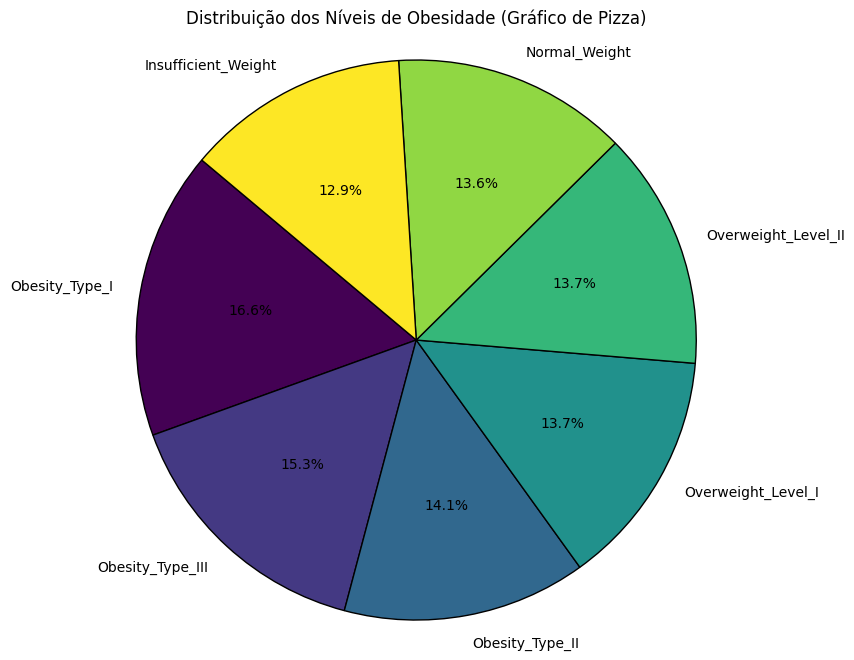

Contagens por categoria:
Obesity
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


In [41]:
# Criar pie chart
plt.figure(figsize=(10, 8))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',  # Mostra percentuais com 1 casa decimal
    startangle=140,     # Ângulo inicial para melhor visualização
    colors=plt.cm.viridis(np.linspace(0, 1, len(labels))),  # Paleta viridis
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}  # Bordas para definição
)
plt.title('Distribuição dos Níveis de Obesidade (Gráfico de Pizza)')
plt.axis('equal')  # Garante que o gráfico seja circular
plt.show()

# Opcional: Imprimir contagens para referência
print("Contagens por categoria:")
print(obesity_counts)

Contagens por MTRANS:
MTRANS
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: count, dtype: int64


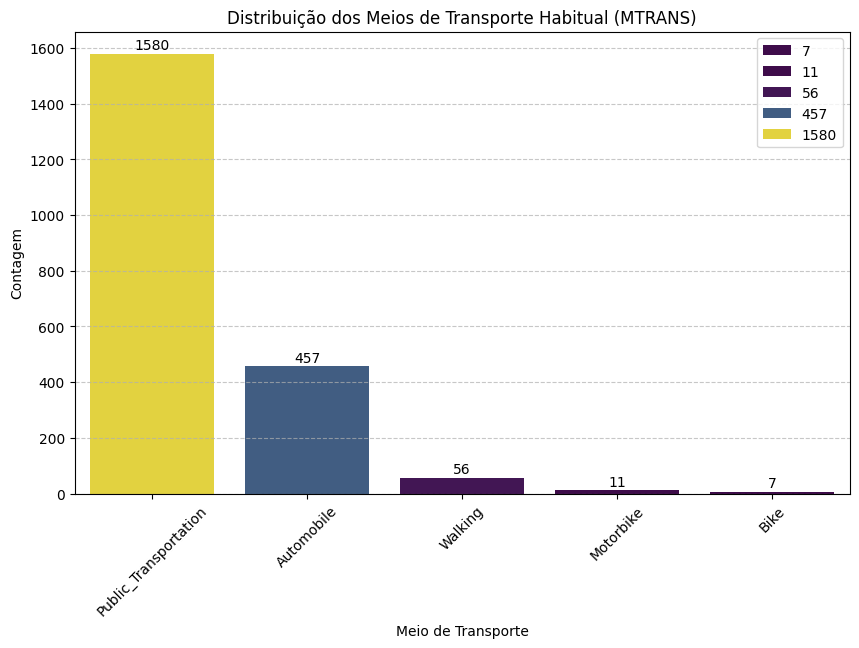

In [42]:
# Contar a frequência de cada meio de transporte
mtrans_counts = df['MTRANS'].value_counts()
print("Contagens por MTRANS:")
print(mtrans_counts)

# Criar bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=mtrans_counts.index, y=mtrans_counts.values, palette='viridis', hue=mtrans_counts.values)
plt.title('Distribuição dos Meios de Transporte Habitual (MTRANS)')
plt.xlabel('Meio de Transporte')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar valores nas barras
for i, v in enumerate(mtrans_counts.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom')

plt.show()


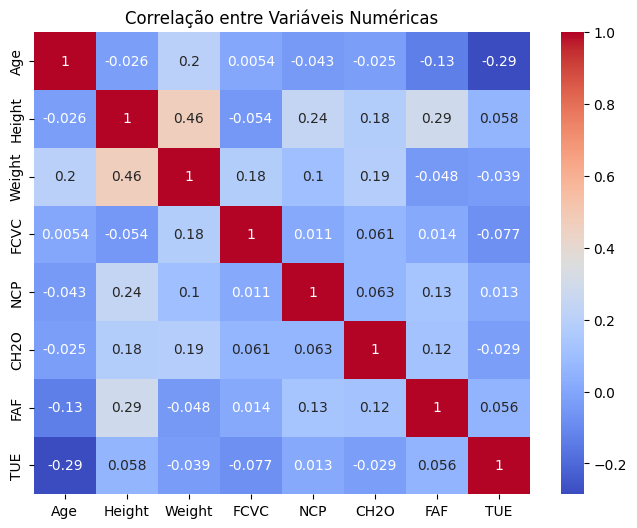

In [43]:
# Correlação entre variáveis numéricas
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlação entre Variáveis Numéricas')
plt.show()

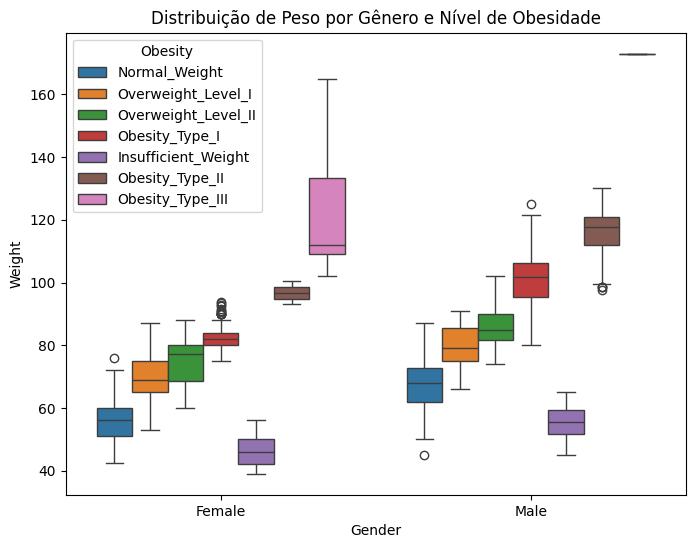

In [44]:
# Distribuição por gênero
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Gender', y='Weight', hue='Obesity')
plt.title('Distribuição de Peso por Gênero e Nível de Obesidade')
plt.show()

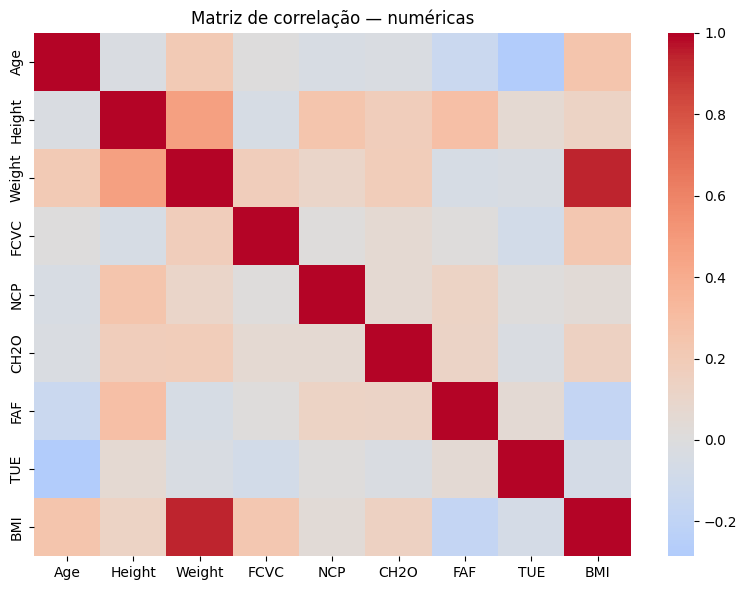

In [45]:
if target_col: 
    px.histogram(df, x=target_col, title=f"Distribuição do alvo: {target_col}", text_auto=True).show()

num_cols_present=[c for c in num_cols if c in df.columns]+(["BMI"] if "BMI" in df.columns else [])

if num_cols_present: 
    px.box(df, y=num_cols_present, points="outliers", title="Boxplots — numéricas").show()

if target_col and "BMI" in df.columns: 
    px.violin(df, x=target_col, y="BMI", box=True, points="outliers", title="BMI por classe").show()

cat_cols_present=[c for c in cat_cols if c in df.columns and c!=target_col]
cat_top=sorted(cat_cols_present, key=lambda c: df[c].nunique())[:6]

for c in cat_top: 
    px.histogram(df, x=c, color=target_col, barmode="group", title=f"{c} × {target_col}").show()

num_for_corr=df.select_dtypes(include="number")

if not num_for_corr.empty:
    plt.figure(figsize=(8,6)); sns.heatmap(num_for_corr.corr(numeric_only=True), cmap="coolwarm", center=0)
    plt.title("Matriz de correlação — numéricas"); plt.tight_layout(); plt.show()

## Shap

SHAP


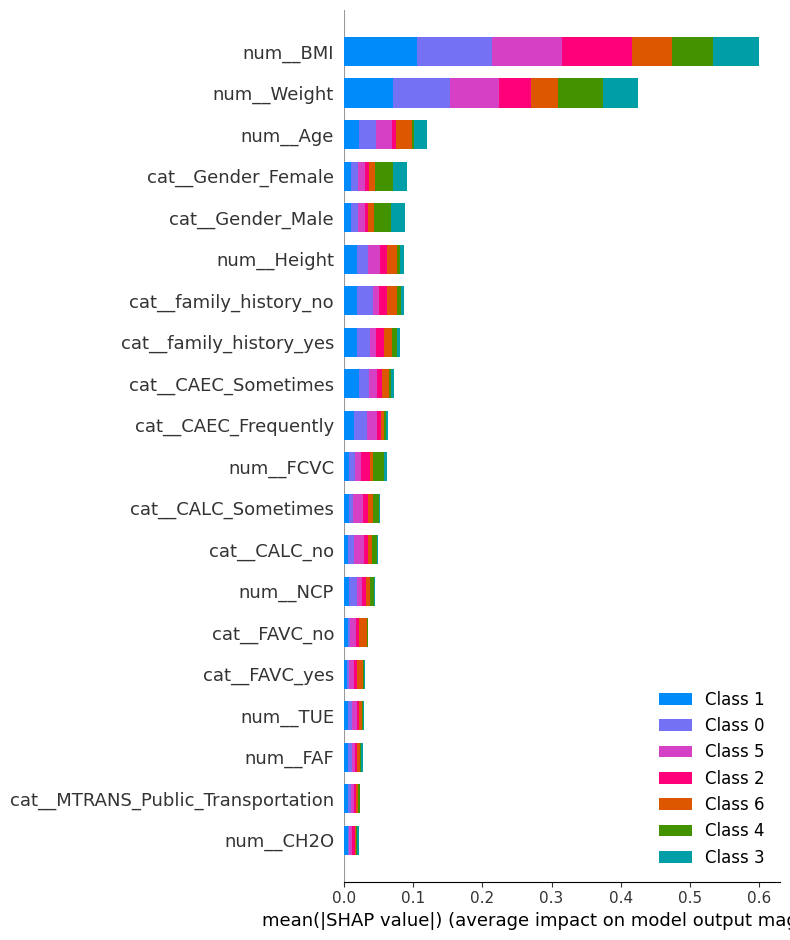

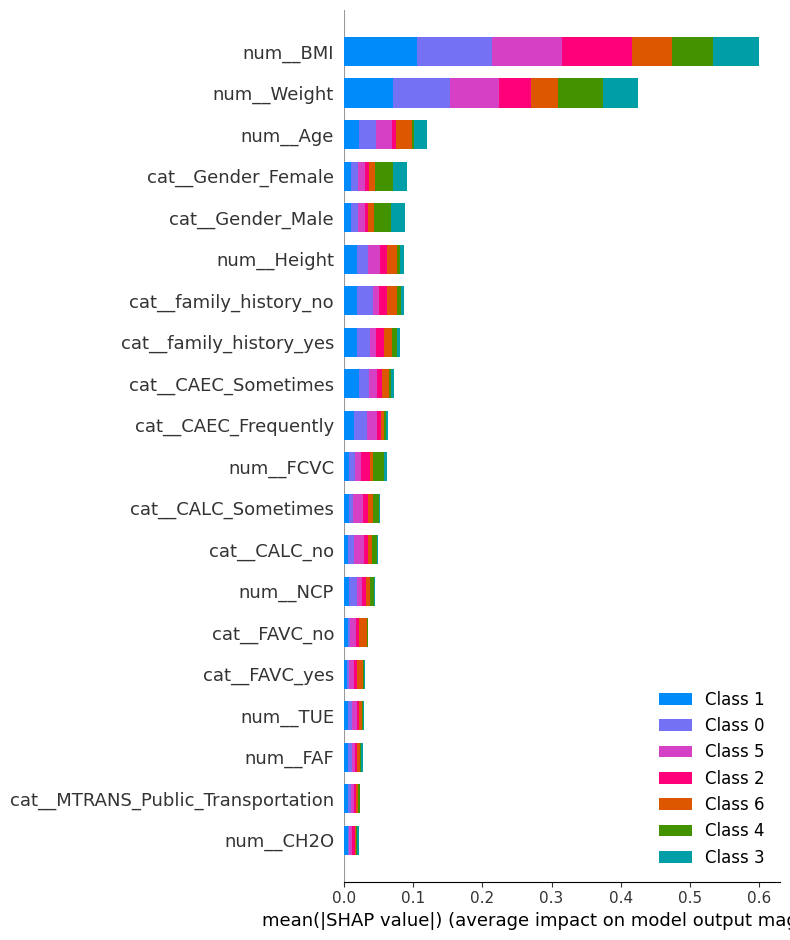

In [46]:
print("SHAP")

# SHAP analysis
features=[c for c in df.columns if c!=target_col and c in (num_cols+cat_cols+["BMI"])]
preprocess = pipeline_model.named_steps.get("prep", None)
estimator = pipeline_model.named_steps.get("model", None)
Xt=preprocess.transform(df[features])

# Get feature names
try: feat_names=preprocess.get_feature_names_out()
except Exception: feat_names=[f"f{i}" for i in range(Xt.shape[1])]

Xt_dense = Xt.toarray() if hasattr(Xt,"toarray") else Xt

try: explainer=shap.TreeExplainer(estimator)
except Exception: explainer=shap.Explainer(estimator, Xt_dense)

sample=Xt_dense[:min(1000, Xt_dense.shape[0])]
sv=explainer(sample)

try: shap.summary_plot(sv, features=sample, feature_names=feat_names, plot_type="bar", show=True)
except Exception: pass

try: shap.summary_plot(sv, features=sample, feature_names=feat_names, show=True)
except Exception: pass

# Métricas

MÉTRICAS
Acurácia: 0.9948

Relatório:
                      precision    recall  f1-score   support

Insufficient_Weight     1.0000    0.9963    0.9982       272
      Normal_Weight     0.9793    0.9895    0.9844       287
     Obesity_Type_I     0.9972    1.0000    0.9986       351
    Obesity_Type_II     0.9966    0.9966    0.9966       297
   Obesity_Type_III     1.0000    0.9969    0.9985       324
 Overweight_Level_I     0.9896    0.9862    0.9879       290
Overweight_Level_II     1.0000    0.9966    0.9983       290

           accuracy                         0.9948      2111
          macro avg     0.9947    0.9946    0.9946      2111
       weighted avg     0.9948    0.9948    0.9948      2111



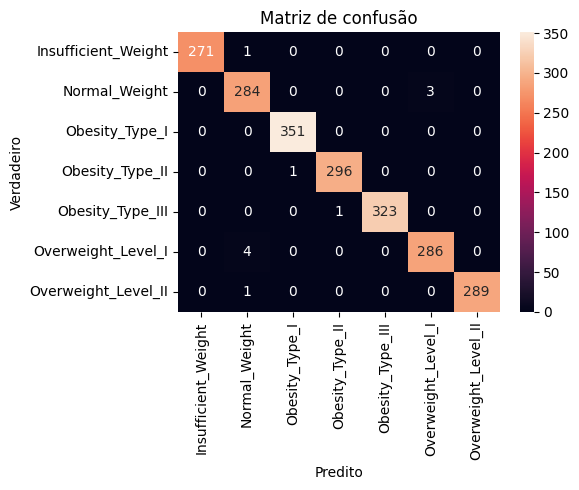

In [47]:
print("MÉTRICAS")

acc=None

if target_col:
    X_in=df[[c for c in df.columns if c in (num_cols+cat_cols+["BMI"])]]
    y_true=df[target_col]
    try:
        y_pred = pipeline_model.predict(X_in)
        acc=float(accuracy_score(y_true,y_pred))
        print("Acurácia:", f"{acc:.4f}")
        print("\nRelatório:\n", classification_report(y_true,y_pred, digits=4))
        labels=sorted(y_true.unique())
        cm=confusion_matrix(y_true,y_pred,labels=labels)
        plt.figure(figsize=(6,5)); sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
        plt.xlabel("Predito"); plt.ylabel("Verdadeiro"); plt.title("Matriz de confusão"); plt.tight_layout(); plt.show()
    except Exception as e:
        print("Falha ao avaliar:", e)
else:
    print("Sem coluna de alvo na base atual.")

# Gera Relatórios

In [48]:
print("RELATÓRIOS")

html_path="reports/Relatorio_TechChallenge_Obesidade.html"; md_path="reports/Relatorio_TechChallenge_Obesidade.md"
key_insights=[f"Tamanho da base: {len(df)}", f"Acurácia (estimada aqui): {acc:.4f}" if acc is not None else "Acurácia não recalculada aqui", "Principais variáveis: BMI, hábitos (FAVC, CAEC, CH2O, FAF), histórico familiar, sexo, idade"]
html="<!DOCTYPE html><html lang='pt-br'><head><meta charset='utf-8'/><title>Relatório — Tech Challenge Obesidade</title><style>body{font-family:Arial;margin:2rem}h1,h2{color:#222}</style></head><body><h1>Relatório — Tech Challenge (Obesidade)</h1><p><strong>Data:</strong> "+datetime.now().strftime("%Y-%m-%d %H:%M:%S")+"</p><h2>Resumo</h2><p>Modelo multi-classe para níveis de obesidade; pipeline completa; deploy via Streamlit.</p><h2>Indicadores</h2><ul>"+("".join([f"<li>{it}</li>" for it in key_insights]))+"</ul><h2>Insights</h2><ul><li>BMI separa parcialmente as classes; hábitos deslocam probabilidade entre faixas vizinhas.</li><li>Consumo de água (CH2O) e atividade física (FAF) correlacionam com classes mais baixas.</li><li>Histórico familiar e consumo calórico (FAVC) elevam risco.</li></ul></body></html>"

open(html_path,"w",encoding="utf-8").write(html)
open(md_path,"w",encoding="utf-8").write("# Relatório — Tech Challenge (Obesidade)\n"+"\n".join([f"- {it}" for it in key_insights]))

print("Gerado:", html_path, "|", md_path)

RELATÓRIOS
Gerado: reports/Relatorio_TechChallenge_Obesidade.html | reports/Relatorio_TechChallenge_Obesidade.md
